## Data Import

##### Importing Libraries

In [121]:
import numpy as np
import pandas as pd 
import os
import random
from tqdm import tqdm
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools
from scipy.stats import mannwhitneyu
import warnings
import mne

init_notebook_mode(connected=True) ## plotly init
seed = 123
random.seed = seed

In [3]:
path_to_train_data = './data/data_kaggle/SMNI_CMI_TRAIN/'
print('Total amount of files in SMNI_CMI_TRAIN directory: ' + str(len(os.listdir(path_to_train_data))))

Total amount of files in SMNI_CMI_TRAIN directory: 468


##### Importing Data

In [4]:
warnings.filterwarnings("ignore", category=FutureWarning) # disable future warnings

filenames_list = os.listdir(path_to_train_data) ## list of file names in the directory
EEG_data = pd.DataFrame({})

for file_name in tqdm(filenames_list):
    temp_df = pd.read_csv(path_to_train_data + file_name) ## read from the file to df
    EEG_data = pd.concat([EEG_data, temp_df], ignore_index=True) ## add the file data to the main df

del(temp_df, filenames_list, file_name)

  0%|          | 0/468 [00:00<?, ?it/s]

100%|██████████| 468/468 [00:57<00:00,  8.13it/s]


##### Dataset Corrections

In [5]:
## remove the unused column
EEG_data = EEG_data.drop(['Unnamed: 0'], axis=1) 

## remove comma sign from stimulus name
EEG_data.loc[EEG_data['matching condition'] == 'S2 nomatch,', 'matching condition'] =  'S2 nomatch' 

## replace some 'sensor position' values
EEG_data.loc[EEG_data['sensor position'] == 'AF1', 'sensor position'] = 'AF3'
EEG_data.loc[EEG_data['sensor position'] == 'AF2', 'sensor position'] = 'AF4'
EEG_data.loc[EEG_data['sensor position'] == 'PO1', 'sensor position'] = 'PO3'
EEG_data.loc[EEG_data['sensor position'] == 'PO2', 'sensor position'] = 'PO4'

## remove rows with undefined positions
EEG_data = EEG_data[(EEG_data['sensor position'] != 'X') & (EEG_data['sensor position'] != 'Y') & (EEG_data['sensor position'] != 'nd')]

##### Initial Dataset Head

In [7]:
EEG_data.head()

,trial number,sensor position,sample num,sensor value,subject identifier,matching condition,channel,name,time
0,0,FP1,0,-8.921,a,S1 obj,0,co2a0000364,0.000000
1,0,FP1,1,-8.433,a,S1 obj,0,co2a0000364,0.003906
2,0,FP1,2,-2.574,a,S1 obj,0,co2a0000364,0.007812
3,0,FP1,3,5.239,a,S1 obj,0,co2a0000364,0.011719
4,0,FP1,4,11.587,a,S1 obj,0,co2a0000364,0.015625


##### Formatting Dataset for Clarity

In [12]:
# transpose the table to make the data extraction easier

transposed_df_list = []

for group_df in tqdm(EEG_data.groupby(['name', 'trial number', 'matching condition', 'sensor position', 'subject identifier'])):
    _df = pd.DataFrame(group_df[1]['sensor value']).T
    _df.columns = [f'sample_{idx}' for idx in range(256)]
    _df['name'] = group_df[0][0]
    _df['trial number'] = group_df[0][1]
    _df['matching condition'] = group_df[0][2]
    _df['sensor position'] = group_df[0][3]
    _df['subject identifier'] = group_df[0][4]
    
    transposed_df_list.append(_df)
    
new_EEG_data = pd.concat(transposed_df_list)
new_EEG_data = new_EEG_data[[*new_EEG_data.columns[-5:],*new_EEG_data.columns[0:-5]]]
new_EEG_data = new_EEG_data.reset_index(drop=True)

del(_df, transposed_df_list, group_df)

100%|██████████| 28548/28548 [00:28<00:00, 999.56it/s] 


##### New Dataset Head

In [13]:
new_EEG_data.head()

,name,trial number,matching condition,sensor position,subject identifier,sample_0,sample_1,sample_2,sample_3,sample_4,...,sample_246,sample_247,sample_248,sample_249,sample_250,sample_251,sample_252,sample_253,sample_254,sample_255
0,co2a0000364,0,S1 obj,AF3,a,-2.146,-2.146,-1.658,-0.682,2.248,...,-1.658,0.295,2.736,4.201,3.713,1.272,-0.682,-0.193,3.225,7.619
1,co2a0000364,0,S1 obj,AF4,a,1.129,0.641,-0.336,-0.824,0.641,...,4.059,-0.336,-2.777,-0.824,3.571,5.035,4.059,2.106,1.617,4.059
2,co2a0000364,0,S1 obj,AF7,a,-16.856,-7.090,7.558,19.277,23.183,...,17.324,9.511,1.699,-2.207,-2.207,1.211,5.117,8.046,10.000,11.464
3,co2a0000364,0,S1 obj,AF8,a,-10.020,-7.090,1.211,10.488,13.906,...,28.554,27.089,15.859,0.722,-10.020,-10.997,-2.696,9.511,18.789,21.230
4,co2a0000364,0,S1 obj,AFZ,a,-0.987,-1.475,-0.987,-0.010,2.431,...,0.478,-0.498,-0.498,0.478,0.966,0.966,0.966,0.478,2.431,5.361


##### Exporting New Dataset

In [15]:
path_to_export_data = './data/formatted/EEG_formatted.csv'
new_EEG_data.to_csv(path_to_export_data)

##### Subject Details

In [27]:
# Create an empty dictionary to store the results
name_info = {}

# Iterate over each unique name in the chunk
for name in new_EEG_data['name'].unique():
    # Filter data for the current name
    name_data = new_EEG_data[new_EEG_data['name'] == name]
    
    # Calculate the number of unique trials and matching conditions
    unique_trials = name_data['trial number'].nunique()
    unique_conditions = name_data['matching condition'].nunique()
    subject_type = name_data['subject identifier'].unique()

    name_info[name] = {'trials': unique_trials, 'conditions': unique_conditions, 'subject identifier': subject_type}

# Convert the dictionary to a DataFrame for better visualization
result_df = pd.DataFrame.from_dict(name_info, orient='index').reset_index()
result_df.columns = ['Name', 'Unique Trials', 'Unique Matching Conditions', 'Subject Identifier']

# Display the first few rows of the result
result_df.head()

del(name, name_data, name_info, subject_type, unique_conditions, unique_trials)

##### OPTIONAL:    Dictionary Creation

In [ ]:
# # Get unique names
# unique_names = EEG_data['name'].unique()

# # Create a dictionary to store dataframes for each unique name
# subjects_EEG_Data = {}

# for n_EEG_data in unique_names:
#     # Filter the dataframe for each unique name and store it in the dictionary
#     subjects_EEG_Data[n_EEG_data] = EEG_data[EEG_data['name'] == n_EEG_data]


# # separate them sorted by trial, maintaining their shape, in ascending order -- would this require I don't ignore index?

## Signal Processing

### Testing Processing Techniques

##### Variable Definitions

In [146]:
channel_list = new_EEG_data['sensor position'].unique().tolist()
channel_map = {channel:counter for counter,channel in enumerate(channel_list)}
channel_map_mne = {
    'AFZ':'AFz', 
    'CPZ':'CPz', 
    'CZ':'Cz', 
    'FCZ':'FCz', 
    'FP1':'Fp1',
    'FP2':'Fp2', 
    'FPZ':'Fpz', 
    'FZ':'Fz', 
    'OZ':'Oz', 
    'POZ':'POz', 
    'PZ':'Pz',
}


##### Function Definitions

In [310]:
def get_record_df(df, name, trial_number, matching_condition, channel_list):
    df_record = df[df['name'].eq(name) & df['trial number'].eq(trial_number) & df['matching condition'].eq(matching_condition)].set_index(['sensor position']).loc[channel_list]
    return df_record

def get_signal_array(df, name, trial_number, matching_condition, channel_list):
    df_record = get_record_df(df, name, trial_number, matching_condition, channel_list)
    return df_record.to_numpy()[:, 4:]

def get_trials_and_conditions(df, name):
    # Filter the DataFrame for the specified name
    filtered_df = df[df['name'] == name]

    # Group by 'trial number' and 'matching condition' to get unique combinations
    trials_conditions = filtered_df.groupby(['trial number', 'matching condition']).size().reset_index()

    # Drop the last column used for size calculation
    trials_conditions.drop(columns=0, inplace=True)

    return trials_conditions


def get_mne_raw_obs(signal_array, channel_list, channel_map_mne):
    # divide by 1000000 because mne raw interprets it as uV
    sig_divided = signal_array / 1e6

    info = mne.create_info(ch_names=channel_list, sfreq=256, ch_types=['eeg']*61)
    mne.rename_channels(info, channel_map_mne)
    raw = mne.io.RawArray(sig_divided, info)
    
    standard_1020_montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(standard_1020_montage)

    return raw

def plot_samples(alc_signal_array, con_signal_array, channels, custom_title):
    fig, axs = plt.subplots(2)
    for channel in channels:
        axs[0].plot(alc_signal_array[channel_map[channel]])

    for channel in channels:
        axs[1].plot(con_signal_array[channel_map[channel]])

    axs[0].set(xlabel='Sample number')
    axs[0].title.set_text("Alcoholic")
    axs[0].legend(channels, loc='upper center', bbox_to_anchor=(0.5, 1.05), fancybox=True, ncol=5)

    axs[1].title.set_text("Control")
    axs[1].set(xlabel='Sample number')
    axs[1].legend(channels, loc='upper center', bbox_to_anchor=(0.5, 1.05), fancybox=True, ncol=5)

    fig.suptitle(f' {custom_title} ', fontsize=20)
    plt.tight_layout()

def filter_signal(signal_array, channel_list, channel_map_mne):
    # raw
    temp_raw = get_mne_raw_obs(signal_array, channel_list, channel_map_mne)
    # notch
    raw_notch = temp_raw.copy().notch_filter(freqs=50, phase='zero', verbose=False)
    # bandpass
    raw_bp = raw_notch.copy().filter(l_freq=0.5, h_freq=32, phase='zero',verbose=False)
    # set Cz reference EEG
    raw_cz_ref = raw_bp.copy().set_eeg_reference(ref_channels=['Cz'])
    # set average reference EEG
    # raw_avg_ref = raw_bp.copy().set_eeg_reference(ref_channels='average')

    # convert to np arr
    cz_arr = np.transpose(raw_cz_ref.to_data_frame().to_numpy()[:,1:])
    # avg_arr = np.transpose(raw_avg_ref.to_data_frame().to_numpy()[:,1:])

    # info = mne.create_info(['STI'], cz_arr.info['sfreq'], ['stim'])
    # stim_raw = mne.io.RawArray(stim_data, info)
    # cz_arr.add_channels([stim_raw], force_update_info=True)
    # events = mne.find_events(raw_cz_ref)
    # print(events, stim_channel='STI 014')

    return cz_arr

def plot_eeg_joint_topomap(signal_array, channel_list, save_path_animation=None, show_names=False, start_time=0.05, end_time=1, step_size=0.1):
    # select channel X,Y format
    montage = mne.channels.make_standard_montage('standard_1020')
    
    # remove channels that don't have X,Y positions
    ch_to_remove = []
    for ch in channel_list:
        if ch not in list(set(montage.ch_names).intersection(channel_list)):
            ch_to_remove.append(channel_list.index(ch))
    arr = np.delete(signal_array.copy(), ch_to_remove, axis=0)
    
    # create info+evoked objects
    info = mne.create_info(ch_names=list(set(montage.ch_names).intersection(channel_list)), sfreq=256, ch_types='eeg')
    evoked = mne.EvokedArray(arr, info)
    
    # set channel X,Y positions
    evoked.set_montage(montage)

    # plot img
    evoked.plot_joint()

def automated_testing(alc, con, custom_channels, channel_list, channel_map_mne):
    # alcoholic
    alc_signal_array = get_signal_array(new_EEG_data, f'co2a0000{alc[0]}', alc[1], alc[2], channel_list)
    # control
    con_signal_array = get_signal_array(new_EEG_data, f'co2c0000{con[0]}', con[1], con[2], channel_list)

    # plot 
    # plot_samples(alc_signal_array, con_signal_array, custom_channels, "Raw")

    # filter signals
    alc_cz_arr = filter_signal(alc_signal_array, channel_list, channel_map_mne)
    con_cz_arr = filter_signal(con_signal_array, channel_list, channel_map_mne)

    # plot
    plot_samples(alc_cz_arr, con_cz_arr, custom_channels, "Cz Reference")
    # plot_samples(alc_avg_arr, con_avg_arr, custom_channels, "Average Reference")

    plot_eeg_joint_topomap(alc_cz_arr, channel_list)
    plot_eeg_joint_topomap(con_cz_arr, channel_list)

##### Testing Plot Stuff

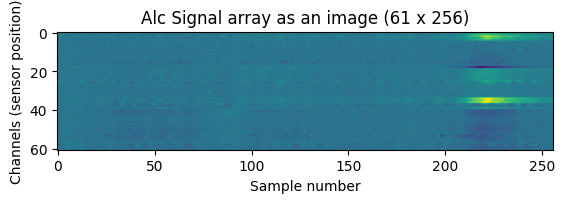

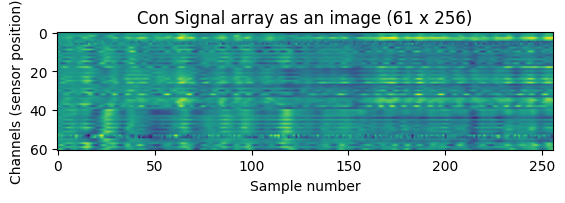

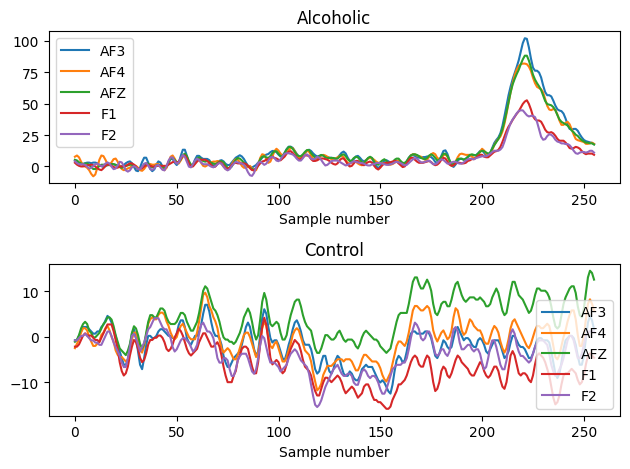

In [249]:
# temp_df = get_trials_and_conditions(new_EEG_data, 'co2a0000364')
# print(temp_df[temp_df['matching condition'] == 'S1 obj'])

# temp_df = get_trials_and_conditions(new_EEG_data, 'co2c0000337')
# print(temp_df[temp_df['matching condition'] == 'S1 obj'])

# del(temp_df)

# alcoholic
signal_array_a = get_signal_array(new_EEG_data, 'co2a0000364', 2, 'S1 obj', channel_list)
# control
signal_array_c = get_signal_array(new_EEG_data, 'co2c0000337', 2, 'S1 obj', channel_list)

plt.title('Alc Signal array as an image (61 x 256)')
plt.ylabel('Channels (sensor position)')
plt.xlabel('Sample number')
plt.imshow(signal_array_a.astype(int))
plt.show()

plt.title('Con Signal array as an image (61 x 256)')
plt.ylabel('Channels (sensor position)')
plt.xlabel('Sample number')
plt.imshow(signal_array_c.astype(int))
plt.show()

# from papers it looks like the following channels are best for EEG
channels_to_display_main = ['FP2', 'PO7', 'PO8', 'P6', 'P5']
# other channels
channels_to_display = ['AF3', 'AF4', 'AFZ', 'F1', 'F2']

plot_samples(signal_array_a, signal_array_c, channels_to_display)

del(channels_to_display, channels_to_display_main)

##### Testing MNE Filter Stuff

Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


C:\Users\chira\AppData\Local\Temp\ipykernel_14296\2240222713.py:4: RuntimeWarning:

filter_length (1691) is longer than the signal (256), distortion is likely. Reduce filter length or filter a longer signal.

C:\Users\chira\AppData\Local\Temp\ipykernel_14296\2240222713.py:6: RuntimeWarning:

filter_length (1691) is longer than the signal (256), distortion is likely. Reduce filter length or filter a longer signal.



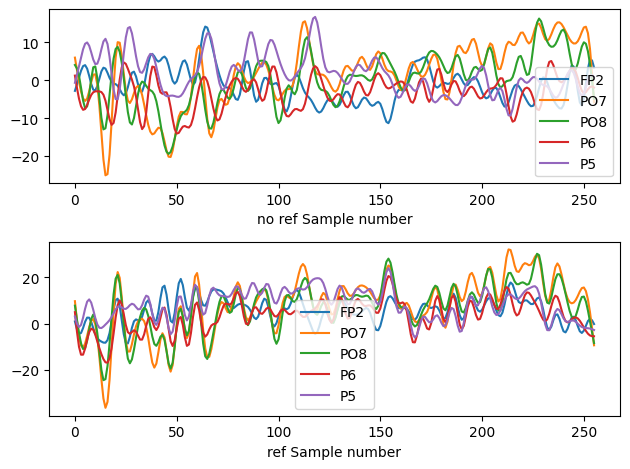

In [245]:
# raw
temp_raw = get_mne_raw_obs(signal_array_c, channel_list, channel_map_mne)
# notch
raw_notch = temp_raw.copy().notch_filter(freqs=50, phase='zero', verbose=False)
# bandpass
raw_bp = raw_notch.copy().filter(l_freq=0.5, h_freq=32, phase='zero',verbose=False)
# raw_bp.compute_psd().plot(show=False)
# raw_bp.compute_psd().plot(average=True)



# set reference EEG
raw_refd = raw_bp.copy().set_eeg_reference(ref_channels=['Cz'])


# other channels
channels_to_display = ['FP2', 'PO7', 'PO8', 'P6', 'P5']

# new_arr = np.transpose(raw_refd.to_data_frame().to_numpy()[:,1:])
# for channel in channels_to_display:
#     plt.xlabel('Sample number')
#     plt.plot(new_arr[channel_list.index(channel)])
# plt.legend(channels_to_display)

fig, axs = plt.subplots(2)
for channel in channels_to_display:
    axs[0].set(xlabel='no ref Sample number')
    axs[0].plot(np.transpose(raw_bp.to_data_frame().to_numpy()[:,1:])[channel_map[channel]])

for channel in channels_to_display:
    axs[1].set(xlabel='ref Sample number')
    axs[1].plot(np.transpose(raw_refd.to_data_frame().to_numpy()[:,1:])[channel_map[channel]])

axs[0].legend(channels_to_display)
axs[1].legend(channels_to_display)
plt.tight_layout()


# del(raw_bp, raw_notch, temp_raw, raw_refd, channel, channels_to_display, new_arr, fig, axs)
del(raw_bp, raw_notch, temp_raw, raw_refd, channel, channels_to_display, fig, axs)

##### Testing Automated Functions

In [307]:
warnings.filterwarnings("ignore", category=RuntimeWarning) # disable future warnings

temp_df = get_trials_and_conditions(new_EEG_data, 'co2a0000364')
print(temp_df[temp_df['matching condition'] == 'S1 obj'])

temp_df = get_trials_and_conditions(new_EEG_data, 'co2c0000337')
print(temp_df[temp_df['matching condition'] == 'S1 obj'])

# from papers it looks like the following channels are best for EEG
channels_to_display_main = ['FP2', 'PO7', 'PO8', 'P6', 'P5']
# other channels
channels_to_display = ['AF3', 'AF4', 'AFZ', 'F1', 'F2']


# automated_testing(["364", 2, "S1 obj"], ["337", 2, "S1 obj"], channels_to_display, channel_list, channel_map_mne)
# automated_testing(["365", 11, "S2 match"], ["338", 11, "S2 match"], channels_to_display, channel_list, channel_map_mne)
# automated_testing(["370", 31, "S2 nomatch"], ["341", 31, "S2 nomatch"], channels_to_display, channel_list, channel_map_mne)
# automated_testing(["370", 23, "S2 match"], ["341", 23, "S2 match"], channels_to_display, channel_list, channel_map_mne)


del(temp_df, channels_to_display, channels_to_display_main)

    trial number matching condition
0              0             S1 obj
1              2             S1 obj
4             10             S1 obj
5             12             S1 obj
6             14             S1 obj
9             18             S1 obj
11            20             S1 obj
12            22             S1 obj
14            24             S1 obj
17            28             S1 obj
    trial number matching condition
0              0             S1 obj
1              2             S1 obj
2             16             S1 obj
6             24             S1 obj
8             26             S1 obj
10            28             S1 obj
12            30             S1 obj
13            32             S1 obj
15            34             S1 obj
16            36             S1 obj


### Process Dataframe

##### Testing Conversion

In [414]:
filtered_df = new_EEG_data.copy()

unique_combinations = filtered_df[['name', 'trial number', 'matching condition', 'sensor position']].drop_duplicates()

# signal analysis
signal_arr = get_signal_array(new_EEG_data, "co2a0000364", 0, 'S1 obj', channel_list)
filtered_signal = filter_signal(signal_arr, channel_list, channel_map_mne)

# Get the boolean mask for the current segment and channel
mask = (
    (new_EEG_data['name'] == "co2a0000364") &
    (new_EEG_data['trial number'] == 0) &
    (new_EEG_data['matching condition'] == "S1 obj") &
    (new_EEG_data['sensor position'] == "CP1")
)

# before change
print(filtered_df.loc[mask])

# get index of dataframe
idx_df = filtered_df.loc[mask].index.tolist()[0]

# use modulus operator to always get row required
filtered_df.iloc[idx_df, 5:261] = filtered_signal[idx_df % 61].tolist()

# after change
print(filtered_df.loc[mask])

# print(filtered_df.iloc[idx_df, 5:261])
# print(filtered_signal[idx_df % 61].tolist())

del(mask, signal_arr, filtered_signal, filtered_df, idx_df)

unique_combinations = new_EEG_data[['name', 'trial number', 'matching condition']].drop_duplicates()
# del(unique_combinations)

Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
           name  trial number matching condition sensor position  \
11  co2a0000364             0             S1 obj             CP1   

   subject identifier  sample_0  sample_1  sample_2  sample_3  sample_4  ...  \
11                  a     -1.77    -0.793    -0.305    -0.305    -0.305  ...   

    sample_246  sample_247  sample_248  sample_249  sample_250  sample_251  \
11       4.578       4.578       3.601       3.113       3.601       4.578   

    sample_252  sample_253  sample_254  sample_255  
11       5.554       5.554       4.578       3.601  

[1 rows x 261 columns]
           name  trial number matching condition sensor position  \
11  co2a0000364             0             S1 obj             CP1   

   subject identifier  sample_0  sample_1  sample_2  sample_3  sample_4  ...  \
11                  a  3.886644  2.632052  0.267453 -3.492145 -7.784542  ...   

    sample_246  sample_247  sample

##### Function Definitions

In [411]:
def filter_dataframe(df, channel_list, channel_map_mne):
    # Create a copy of the DataFrame to avoid modifying the original data
    df_filtered = df.copy()

    # Get unique combinations of 'name', 'trial number', 'matching condition', and 'sensor position'
    unique_combinations = df_filtered[['name', 'trial number', 'matching condition', 'sensor position']].drop_duplicates()

    for _, row in unique_combinations.iterrows():
        
        # initial matching condition to initialize variables
        if row['sensor position'] == 'AF3':
            name = row['name']
            trial_number = row['trial number']
            matching_condition = row['matching condition']
            
            # Apply the filtering function
            signal_array = get_signal_array(df, name, trial_number, matching_condition, channel_list)
            filtered_signal = filter_signal(signal_array, channel_list, channel_map_mne)
        
        mask = (
            (df_filtered['name'] == name) &
            (df_filtered['trial number'] == trial_number) &
            (df_filtered['matching condition'] == matching_condition) &
            (df_filtered['sensor position'] == row['sensor position'])
        )
        
        # get index of dataframe
        idx_df = df_filtered.loc[mask].index.tolist()[0]
        print(idx_df)

        # replace the data
        df_filtered.iloc[idx_df, 5:261] = filtered_signal[idx_df % 61].tolist()

    return df_filtered

##### Process the Dataframe

In [410]:
filt_EEG_data = filter_dataframe(new_EEG_data, channel_list, channel_map_mne)

Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255

##### Export to CSV

In [509]:
filt_EEG_data.to_csv(path_to_export_data)

### Testing Feature Extraction Methods

##### Testing Implementation

In [495]:
filt_EEG_data.groupby(['name', 'matching condition', 'sensor position']).sum()

# filt_EEG_data.columns[-256:]
# pd.DataFrame(columns=filt_EEG_data.columns)


# conditions = ['S1 obj', 'S2 match', 'S2 nomatch']
# repetitions_per_condition = 61
# total_repetitions = 16

# # Generate the list
# averaged_matching_conditions = [condition for condition in conditions for _ in range(repetitions_per_condition)] * total_repetitions

# del(conditions, repetitions_per_condition, total_repetitions, averaged_matching_conditions)


# df_name = filt_EEG_data[filt_EEG_data['name'] == 'co2a0000364']

# # Group by 'matching condition' and count unique 'trial number'
# condition_counts = df_name.groupby('matching condition')['trial number'].nunique().reset_index()

# print(condition_counts.iloc[0]['trial number'])

# del(df_name, condition_counts)



# count_df = filt_EEG_data.groupby(['name', 'matching condition'])['trial number'].nunique()

# avg_df = sum_df.div(count_df, axis='index').reset_index()

# del (sum_df, count_df)

trial number  \
name        matching condition sensor position                 
co2a0000364 S1 obj             AF3                       150   
                               AF4                       150   
                               AF7                       150   
                               AF8                       150   
                               AFZ                       150   
...                                                      ...   
co2c0000345 S2 nomatch         PZ                        173   
                               T7                        173   
                               T8                        173   
                               TP7                       173   
                               TP8                       173   

                                               subject identifier   sample_0  \
name        matching condition sensor position                                 
co2a0000364 S1 obj             AF3                     aaaaaaaaaa   4.606920   
                               AF4                     aaaaaaaaaa   4.596980   
                               AF7                     aaaaaaaaaa  -4.829976   
                               AF8                     aaaaaaaaaa   3.237674   
                               AFZ                     aaaaaaaaaa   4.630711   
...                                                           ...        ...   
co2c0000345 S2 nomatch         PZ                       ccccccccc -10.285695   
                               T7                       ccccccccc  -8.182051   
                               T8                       ccccccccc -14.825897   
                               TP7                      ccccccccc  -2.509763   
                               TP8                      ccccccccc -14.664873   

                                                 sample_1   sample_2  \
name        matching condition sensor position                         
co2a0000364 S1 obj             AF3              -7.088074 -18.486620   
                               AF4               1.761554  -4.253795   
                               AF7               5.768554  12.815943   
                               AF8              -7.329313 -14.119309   
                               AFZ              -4.037150 -13.368655   
...                                                   ...        ...   
co2c0000345 S2 nomatch         PZ               -0.699238   6.968999   
                               T7               -5.345625  -4.602255   
                               T8              -11.495757  -7.114216   
                               TP7              -2.656922  -2.902634   
                               TP8              -3.658923   5.887246   

                                                 sample_3   sample_4  \
name        matching condition sensor position                         
co2a0000364 S1 obj             AF3             -28.177440 -33.653153   
                               AF4             -14.011219 -24.626246   
                               AF7              15.061107  14.117651   
                               AF8             -16.558721 -17.954817   
                               AFZ             -22.423098 -28.486171   
...                                                   ...        ...   
co2c0000345 S2 nomatch         PZ               11.232489  11.387629   
                               T7               -6.944598 -11.796204   
                               T8               -1.554757   4.069455   
                               TP7              -3.391552  -4.308867   
                               TP8              12.859135  16.727355   

                                                 sample_5   sample_6  \
name        matching condition sensor position                         
co2a0000364 S1 obj             AF3             -32.694768 -25.218270   
                               AF4             -31.337509 -30.499237   
            

##### Function Definitions

In [507]:
def sum_trials(df, channel_list):
    df_averaged = pd.DataFrame(columns=df.columns)
    df_averaged = df_averaged.drop(['trial number'], axis=1)
    df_averaged = df_averaged.drop(['matching condition'], axis=1)
    summed_sensor_values_df = df.groupby(['name', 'matching condition', 'sensor position']).sum()
    matched_cond_list = ['S1 obj', 'S2 match', 'S2 nomatch']
    sen_vals_names = df.columns[-256:]

    for name_counter, name in enumerate(new_EEG_data['name'].unique()):
        for mc_counter, mc in enumerate(matched_cond_list):
            mc_len = len(matched_cond_list)
            for channel_counter, channel in enumerate(channel_list):
                cl_len = len(channel_list)
                # find index
                idx_df = channel_counter + cl_len*(mc_counter + mc_len*(name_counter))

                # Group by 'matching condition' and count unique 'trial number'
                df_name = df[df['name'] == name]
                condition_counts = df_name.groupby('matching condition')['trial number'].nunique().reset_index()
                num_conditions = condition_counts.iloc[mc_counter]['trial number']

                # format DataFrame
                df_averaged['name'] = name
                print(df_averaged)
                df_averaged[idx_df, 'name'] = name
                print(df_averaged)
                print(name)
                return
                df_averaged['sensor position'] = channel
                df_averaged['subject identifier'] = df.iloc[idx_df, 4]
                df_averaged[sen_vals_names] = summed_sensor_values_df.iloc[idx_df, 2:261].div(num_conditions)
                # df_averaged['sample_0':'sample_255'] = summed_sensor_values_df.iloc[idx_df, 2:261].div(num_conditions)

        print(idx_df)
    
    # create a matching condition average column
    # Generate the list
    averaged_matching_conditions = [condition for condition in matched_cond_list for _ in range(61)] * 16
    df_averaged.insert(1, "averaged matching conditions", averaged_matching_conditions)

    return df_averaged

##### Process the Averaged Dataframe

In [508]:
mc_avg_EEG_data = sum_trials(filt_EEG_data, channel_list)

Empty DataFrame
Columns: [name, sensor position, subject identifier, sample_0, sample_1, sample_2, sample_3, sample_4, sample_5, sample_6, sample_7, sample_8, sample_9, sample_10, sample_11, sample_12, sample_13, sample_14, sample_15, sample_16, sample_17, sample_18, sample_19, sample_20, sample_21, sample_22, sample_23, sample_24, sample_25, sample_26, sample_27, sample_28, sample_29, sample_30, sample_31, sample_32, sample_33, sample_34, sample_35, sample_36, sample_37, sample_38, sample_39, sample_40, sample_41, sample_42, sample_43, sample_44, sample_45, sample_46, sample_47, sample_48, sample_49, sample_50, sample_51, sample_52, sample_53, sample_54, sample_55, sample_56, sample_57, sample_58, sample_59, sample_60, sample_61, sample_62, sample_63, sample_64, sample_65, sample_66, sample_67, sample_68, sample_69, sample_70, sample_71, sample_72, sample_73, sample_74, sample_75, sample_76, sample_77, sample_78, sample_79, sample_80, sample_81, sample_82, sample_83, sample_84, sample